# Lab 3: Histogram - Atomic Operations

---

## Overview

This lab explores the **histogram problem**, a classic example that demonstrates the challenges of parallel programming when multiple threads need to update shared data. You will learn how **atomic operations** solve race conditions and how **shared memory privatization** dramatically improves performance.

Building on Lab 2's introduction to shared memory for data movement (matrix transpose), this lab shows how shared memory reduces **atomic contention** in accumulation patterns.

Histograms are fundamental to many algorithms including image processing, data analysis, and machine learning preprocessing.

## Learning Objectives

By the end of this lab, you will be able to:

1. Identify race conditions in parallel programs
2. Use atomic operations (`atomicAdd`) to safely update shared data
3. Understand the performance cost of atomic contention
4. Implement two-level histogram reduction using shared memory
5. Analyze memory access patterns and their impact on performance

## 1. The Histogram Problem

### Sequential Algorithm

The serial implementation is straightforward:

```cpp
void serial_histogram(const int* input, int* histogram, int N, int num_bins) {
    // Initialize histogram to zero
    for (int i = 0; i < num_bins; i++) {
        histogram[i] = 0;
    }
    // Count occurrences
    for (int i = 0; i < N; i++) {
        histogram[input[i]]++;
    }
}
```

### The Parallelization Challenge

When multiple threads try to increment the same histogram bin simultaneously, we have a **race condition**:

```
Thread A reads histogram[5] = 10
Thread B reads histogram[5] = 10
Thread A writes histogram[5] = 11
Thread B writes histogram[5] = 11  <-- Lost update!
```

The correct value should be 12, but we get 11. This is called a **lost update**.

## 2. Atomic Operations

**Atomic operations** guarantee that a read-modify-write sequence completes without interruption from other threads.

### atomicAdd

```cpp
atomicAdd(&histogram[bin], 1);
```

This ensures that even if multiple threads try to update the same bin, each increment is correctly applied.

> **Platform note**: This lab targets **RDNA 3.5 wave32** (Radeon 8060S, gfx1151). Atomic contention is measured per 32-thread wavefront.

### Cost of Atomics

| Aspect | Impact |
|:-------|:-------|
| **Serialization** | Conflicting atomics are serialized |
| **Latency** | Higher latency than regular memory operations |
| **Contention** | Performance degrades with more conflicts |

## 3. Setup: Generate Test Data

In [1]:
%%bash
# Generate test cases
python3 geninput.py
echo "Test cases generated in testcases/"
ls -la testcases/
echo ""
echo "Note: Large files (testcase 4: 100M elements) take time to read from disk."
echo "GPU advantage is most visible with large datasets and excludes file I/O time."

  testcases/1.in: 7 bytes
    N=1, num_bins=10
  testcases/2.in: 28,438,189 bytes
    N=10,000,000, num_bins=64
  testcases/3.in: 37,852,712 bytes
    N=10,000,000, num_bins=512
  testcases/4.in: 378,516,511 bytes
    N=100,000,000, num_bins=512
  testcases/5.in: 400,000,014 bytes
    N=100,000,000, num_bins=256
  testcases/6.in: 391,601,489 bytes
    N=100,000,000, num_bins=1024
Test cases generated in testcases/
total 1207452
drwxr-xr-x 2 jovyan users      4096 Jun  6 05:43 .
drwxrwxrwx 1 jovyan users      4096 Jun  6 05:42 ..
-rw-r--r-- 1 jovyan users         7 Jun  6 05:42 1.in
-rw-r--r-- 1 jovyan users  28438189 Jun  6 05:42 2.in
-rw-r--r-- 1 jovyan users  37852712 Jun  6 05:42 3.in
-rw-r--r-- 1 jovyan users 378516511 Jun  6 05:43 4.in
-rw-r--r-- 1 jovyan users 400000014 Jun  6 05:43 5.in
-rw-r--r-- 1 jovyan users 391601489 Jun  6 05:43 6.in

Note: Large files (testcase 4: 100M elements) take time to read from disk.
GPU advantage is most visible with large datasets and excludes fi

## 4. Compile All Implementations

In [2]:
%%bash
# All three implementations now print "KERNEL_MS <ms>" on stderr
# (HIP events for GPU, std::chrono for serial). Recompile.
g++ -O2 fs_serial.cpp -o exe_serial
hipcc -O2 fs_bad.hip  -o exe_bad
hipcc -O2 fs_main.hip -o exe_optimized
echo "Compilation complete."

fs_bad.hip:41:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   41 |     hipMalloc(&d_input, N * sizeof(int));
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fs_bad.hip:42:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   42 |     hipMalloc(&d_histogram, num_bins * sizeof(int));
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fs_bad.hip:44:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   44 |     hipMemcpy(d_input, input, N * sizeof(int), hipMemcpyHostToDevice);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fs_bad.hip:47:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   47 |     hipMemset(d_histogram, 0, num_bins * sizeof(int));
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fs_bad.hip

Compilation complete.


## 5. Approach 1: Naive Parallel Histogram (Bad Implementation)

Let us examine the naive approach in `fs_bad.hip`.

### Algorithm

Each block is responsible for counting **one specific bin**:

```cpp
__global__ void kernel(const int *input, int *histogram, int N, int num_bins) {
    __shared__ int sdata[1024];
    
    int tidx = threadIdx.x;
    int whichnumbins = blockIdx.x;  // Each block handles one bin
    
    sdata[tidx] = 0;
    
    // Each thread scans entire array looking for matches
    for (int i = tidx; i < N; i += blockDim.x) {
        if (input[i] == whichnumbins) 
            sdata[tidx]++;
    }
    __syncthreads();
    
    // Reduction to sum counts
    for (int i = blockDim.x / 2; i > 0; i >>= 1) {
        if (tidx < i) sdata[tidx] += sdata[tidx + i];
        __syncthreads();
    }
    
    if (tidx == 0) histogram[whichnumbins] = sdata[0];
}
```

### Exercise 1: Analyze the Problem

**Question 1**: How many times is each input element read from global memory?

Your answer: ______

**Question 2**: If num_bins = 256 and N = 10M, what is the total global memory traffic?

Your calculation: ______

**Question 3**: Why is this approach inefficient?

Your answer: ______

### Answers

1. Each input element is read `num_bins` times, because each bin has one block and every block scans the entire input array.
2. The kernel performs `N * num_bins = 10,000,000 * 256 = 2,560,000,000` integer reads. Since each integer is 4 bytes, this is `10,240,000,000` bytes, about `10.24 GB` of global-memory read traffic.
3. It repeatedly scans the entire input once per bin, so work and memory traffic scale as `O(N * num_bins)` instead of `O(N)`. Most reads are wasted because each block only counts one value, and repeated global-memory traffic dominates runtime.


In [ ]:
%%bash
# Quick sanity run of the bad implementation
./exe_bad testcases/2.in > /dev/null && echo "Naive run OK"

## 6. Approach 2: Shared Memory with Atomics (Optimized)

The optimized implementation in `fs_main.hip` uses a two-level approach:

### Algorithm

```cpp
__global__ void kernel(const int* input, int* histogram, int N, int num_bins) {
    __shared__ int sdata[1024];  // Local histogram per block
    
    int idx = threadIdx.x + blockIdx.x * blockDim.x;
    int totalthread = blockDim.x * gridDim.x;

    // Step 1: Initialize shared memory histogram
    for (int i = threadIdx.x; i < num_bins; i += blockDim.x) {
        sdata[i] = 0;
    }
    __syncthreads();

    // Step 2: Accumulate into shared memory (local atomics)
    for (int i = idx; i < N; i += totalthread) {
        atomicAdd(&sdata[input[i]], 1);
    }
    __syncthreads();
    
    // Step 3: Merge local histograms into global (global atomics)
    for (int i = threadIdx.x; i < num_bins; i += blockDim.x) {
        atomicAdd(&histogram[i], sdata[i]);
    }
}
```

### Key Optimization: Two-Level Accumulation

| Level | Memory | Latency | Contention |
|:------|:-------|:--------|:-----------|
| Block-local | Shared Memory (LDS) | Low (~20 cycles) | Only within block |
| Global merge | Global Memory (HBM) | High (~400 cycles) | Reduced (one per block) |

### Exercise 2: Understand the Optimization

**Question 1**: Why is atomicAdd on shared memory faster than on global memory?

Your answer: ______

**Question 2**: In the merge step, how many global atomicAdd operations occur per bin?

Your answer: ______

**Question 3**: What is the purpose of the grid-stride loop pattern `for (int i = idx; i < N; i += totalthread)`?

Your answer: ______

### Answers

1. Shared memory is on-chip LDS with much lower latency and higher bandwidth than global memory. Atomic conflicts are limited to threads within one block, while global-memory atomics contend across the whole grid and require slower off-chip memory operations.
2. One global `atomicAdd` per block per bin. Each block first builds a local shared-memory histogram, then contributes one accumulated count for each bin to the global histogram.
3. The grid-stride loop lets all launched threads cooperatively cover an input array of any size. Each thread processes multiple elements separated by the total number of launched threads, so every input element is read once without requiring one thread per element.


In [3]:
%%bash
# Quick sanity run of the optimized implementation + correctness check
./exe_optimized testcases/2.in > result_opt.txt
./exe_serial    testcases/2.in > result_serial.txt
diff -q result_serial.txt result_opt.txt && echo "Optimized matches serial"

KERNEL_MS 0.473078
KERNEL_MS 2.35878


Optimized matches serial


## 7. Performance Comparison (real compute time)

The previous version measured **wall time** via `subprocess`, which was dominated by file I/O, GPU init, and stdout printing — the real differences between implementations were invisible.

Now each executable prints `KERNEL_MS <ms>` to stderr:
- `exe_serial`: `std::chrono` around `serial_histogram()` only (no file I/O)
- `exe_bad`, `exe_optimized`: HIP events around the GPU kernel (no H2D/D2H, no init)

We parse this number to get a fair compute-only comparison.

In [4]:
import subprocess, re, statistics

# Multi-trial benchmark — parse REAL compute time from stderr (KERNEL_MS)
TRIALS = 5
KERN_RE = re.compile(r"KERNEL_MS\s+([0-9.eE+-]+)")

impls = [
    ("Serial CPU",    "./exe_serial"),
    ("Naive GPU",     "./exe_bad"),
    ("Optimized GPU", "./exe_optimized"),
]
testcases = [
    ("Test 2 (medium)", "testcases/2.in"),
    ("Test 4 (large)",  "testcases/4.in"),
]

def run_once(exe, path):
    r = subprocess.run([exe, path], capture_output=True, text=True)
    m = KERN_RE.search(r.stderr)
    if not m:
        raise RuntimeError(f"No KERNEL_MS from {exe} {path}: {r.stderr[:200]}")
    return float(m.group(1))

results = {}  # results[testcase][impl] = list of ms
for tc_name, tc_path in testcases:
    results[tc_name] = {}
    for impl_name, exe in impls:
        times = [run_once(exe, tc_path) for _ in range(TRIALS)]
        results[tc_name][impl_name] = times
        m, s = statistics.mean(times), statistics.stdev(times) if len(times) > 1 else 0.0
        print(f"{tc_name:<18} {impl_name:<15} mean={m:10.4f} ms  std={s:8.4f} ms")
    print()

Test 2 (medium)    Serial CPU      mean=    2.5611 ms  std=  0.4196 ms
Test 2 (medium)    Naive GPU       mean=   15.0112 ms  std=  4.1973 ms
Test 2 (medium)    Optimized GPU   mean=    0.4570 ms  std=  0.0071 ms

Test 4 (large)     Serial CPU      mean=   22.8836 ms  std=  0.2577 ms
Test 4 (large)     Naive GPU       mean= 2549.3780 ms  std= 20.3890 ms
Test 4 (large)     Optimized GPU   mean=    4.4452 ms  std=  0.0037 ms



### Exercise 3: Record Results

Fill in the execution times:

| Implementation | Time (testcase 2) | Time (testcase 4) |
|:---------------|:------------------|:------------------|
| Serial (CPU) | ______ | ______ |
| Naive GPU | ______ | ______ |
| Optimized GPU | ______ | ______ |

Calculate speedups:

- Optimized vs Serial: ______ x
- Optimized vs Naive: ______ x

### Answers

| Implementation | Time (testcase 2) | Time (testcase 4) |
|:--|:--|:--|
| Serial (CPU) | `2.5611 ms` | `22.8836 ms` |
| Naive GPU | `15.0112 ms` | `2549.3780 ms` |
| Optimized GPU | `0.4570 ms` | `4.4452 ms` |

- Optimized vs Serial: `2.5611 / 0.4570 = 5.60x` on testcase 2; `22.8836 / 4.4452 = 5.15x` on testcase 4.
- Optimized vs Naive: `15.0112 / 0.4570 = 32.85x` on testcase 2; `2549.3780 / 4.4452 = 573.50x` on testcase 4.


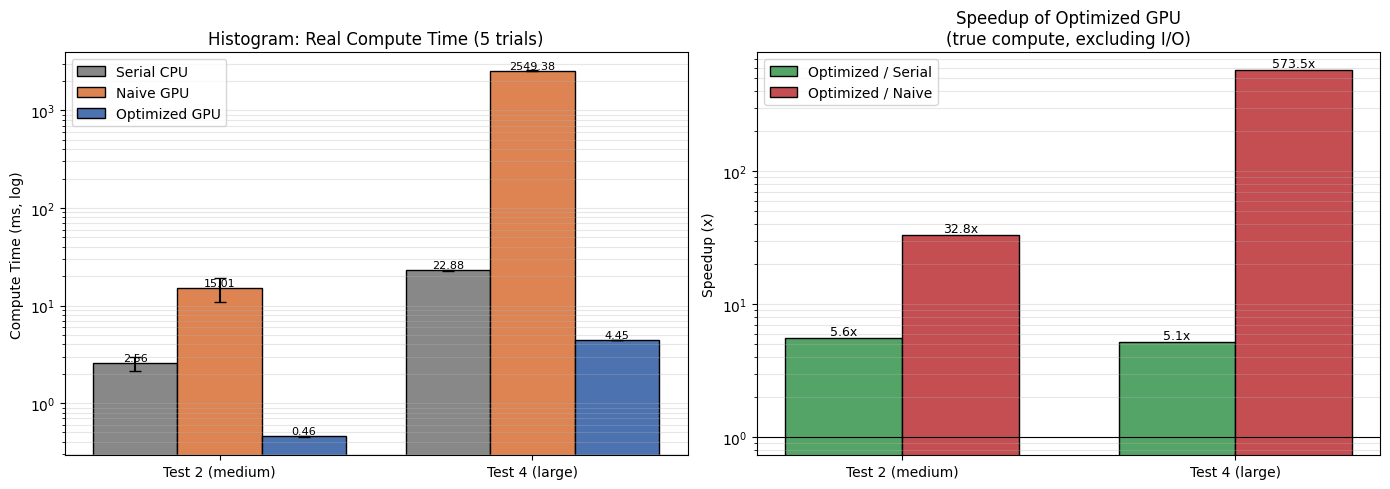

Saved: histogram_perf.png

=== Interpretation ===
- Optimized GPU: each element read once + atomics on LDS -> very fast
- Naive GPU:     each block scans entire input (N * num_bins reads) -> slow
- Serial CPU:    O(N) but single-threaded -> baseline
- Real speedups now visible (previously hidden by file I/O & stdout)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

impl_names = [n for n, _ in impls]
tc_names   = list(results.keys())
colors     = ['#888888', '#dd8452', '#4c72b0']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart per testcase (log scale)
x = np.arange(len(tc_names))
w = 0.27
for i, impl in enumerate(impl_names):
    means = [statistics.mean(results[tc][impl]) for tc in tc_names]
    stds  = [statistics.stdev(results[tc][impl]) if len(results[tc][impl]) > 1 else 0.0
             for tc in tc_names]
    bars = ax1.bar(x + (i - 1) * w, means, w, yerr=stds, capsize=4,
                   label=impl, color=colors[i], edgecolor='black')
    for b, m in zip(bars, means):
        ax1.text(b.get_x() + b.get_width()/2, m, f"{m:.2f}",
                 ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(tc_names)
ax1.set_ylabel("Compute Time (ms, log)")
ax1.set_yscale('log')
ax1.set_title(f"Histogram: Real Compute Time ({TRIALS} trials)")
ax1.legend(); ax1.grid(axis='y', alpha=0.3, which='both')

# Right: speedup of optimized over naive and serial
speedup_vs_serial = [statistics.mean(results[tc]["Serial CPU"]) /
                     statistics.mean(results[tc]["Optimized GPU"]) for tc in tc_names]
speedup_vs_naive  = [statistics.mean(results[tc]["Naive GPU"]) /
                     statistics.mean(results[tc]["Optimized GPU"]) for tc in tc_names]

w2 = 0.35
ax2.bar(x - w2/2, speedup_vs_serial, w2, label="Optimized / Serial",
        color='#55a467', edgecolor='black')
ax2.bar(x + w2/2, speedup_vs_naive,  w2, label="Optimized / Naive",
        color='#c44e52', edgecolor='black')
for i, (s1, s2) in enumerate(zip(speedup_vs_serial, speedup_vs_naive)):
    ax2.text(i - w2/2, s1, f"{s1:.1f}x", ha='center', va='bottom', fontsize=9)
    ax2.text(i + w2/2, s2, f"{s2:.1f}x", ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(tc_names)
ax2.set_ylabel("Speedup (x)")
ax2.set_yscale('log')
ax2.set_title("Speedup of Optimized GPU\n(true compute, excluding I/O)")
ax2.axhline(1, color='black', linewidth=0.8)
ax2.legend(); ax2.grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
plt.savefig("histogram_perf.png", dpi=150)
plt.show()
print("Saved: histogram_perf.png")
print()
print("=== Interpretation ===")
print("- Optimized GPU: each element read once + atomics on LDS -> very fast")
print("- Naive GPU:     each block scans entire input (N * num_bins reads) -> slow")
print("- Serial CPU:    O(N) but single-threaded -> baseline")
print("- Real speedups now visible (previously hidden by file I/O & stdout)")

## 8. Memory Access Pattern Analysis

### Naive Approach Memory Traffic

- Each block reads the **entire input array**
- Total reads = N x num_bins
- Example: N=10M, bins=256 → 2.56 billion reads

### Optimized Approach Memory Traffic

- Each element is read exactly **once** from global memory
- Total reads = N
- Example: N=10M → 10 million reads

### Exercise 4: Memory Efficiency

**Question**: Calculate the memory traffic reduction ratio:

$$
\text{Reduction} = \frac{\text{Naive reads}}{\text{Optimized reads}} = \frac{N \times \text{num\_bins}}{N} = ?
$$

Your answer: ______

### Answers

The reduction ratio is `num_bins`. For example, with 256 bins, the optimized approach reduces global input reads by `256x`; with 64 bins, it reduces them by `64x`.


## 9. Contention Analysis

### When Does Contention Occur?

Atomic contention happens when multiple threads try to update the same memory location simultaneously.

### Factors Affecting Contention

| Factor | Low Contention | High Contention |
|:-------|:---------------|:----------------|
| Number of bins | Many bins | Few bins |
| Data distribution | Uniform | Skewed |
| Memory level | Shared | Global |

### Exercise 5: Contention Scenarios

**Scenario 1**: All input values are the same (e.g., all zeros)

- What happens to performance? ______
- Why? ______

**Scenario 2**: Input values are uniformly distributed across all bins

- Expected contention level: ______
- Why? ______

### Answers

**Scenario 1:** Performance becomes slower; in the measured output, all-same data took `0.6802 ms`, compared with `0.4543 ms` for uniform data. This happens because every thread updates the same bin, so atomic operations serialize heavily. In the optimized kernel this contention happens in shared memory, so it is still much cheaper than global contention, but it remains the worst-case distribution.

**Scenario 2:** Expected contention is low relative to skewed or all-same input. Updates are spread across many bins, so fewer threads in the same block or wavefront try to atomically update the same shared-memory location at the same time.


Uniform        mean=  0.4543 ms  std=0.0064
Gaussian       mean=  0.4518 ms  std=0.0051
All-same(0)    mean=  0.6802 ms  std=0.0064


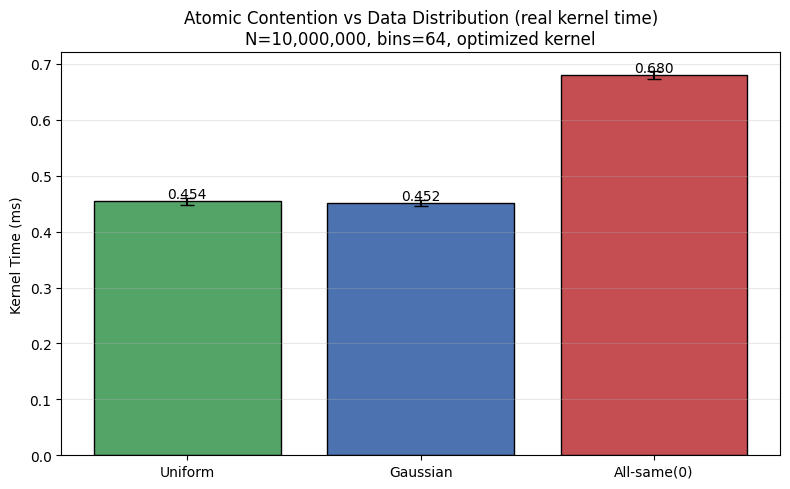


=== Interpretation ===
- Uniform:     atomics spread across 64 bins -> minimal LDS contention
- Gaussian:    most hits cluster near center bin -> moderate contention
- All-same(0): every wave32 lane targets bin 0 -> maximum contention, slowest
- The shared-memory privatization caps the cost: only LDS atomics collide,
  not global atomics, so the slowdown is bounded.


In [6]:
import numpy as np, os, subprocess, re, statistics
import matplotlib.pyplot as plt

# Atomic contention experiment — use REAL kernel time so the differences
# between distributions are not drowned in I/O.
os.makedirs("testcases_dist", exist_ok=True)
N, NUM_BINS = 10_000_000, 64
KERN_RE = re.compile(r"KERNEL_MS\s+([0-9.eE+-]+)")

def write_case(path, data):
    with open(path, "w") as f:
        f.write(f"{N} {NUM_BINS}\n")
        f.write(" ".join(map(str, data.tolist())))

rng = np.random.default_rng(0)
dists = {
    "Uniform":     rng.integers(0, NUM_BINS, N),
    "Gaussian":    np.clip(rng.normal(NUM_BINS/2, NUM_BINS/8, N).astype(int), 0, NUM_BINS-1),
    "All-same(0)": np.zeros(N, dtype=int),
}
paths = {n: f"testcases_dist/{n}.in" for n in dists}
for n, d in dists.items():
    if not os.path.exists(paths[n]):
        write_case(paths[n], d)

TRIALS = 5
dist_times = {}
for name, p in paths.items():
    ts = []
    for _ in range(TRIALS):
        r = subprocess.run(["./exe_optimized", p], capture_output=True, text=True)
        m = KERN_RE.search(r.stderr)
        if not m:
            raise RuntimeError(f"No KERNEL_MS for {p}")
        ts.append(float(m.group(1)))
    dist_times[name] = ts
    print(f"{name:<14} mean={statistics.mean(ts):8.4f} ms  std={statistics.stdev(ts):6.4f}")

means = [statistics.mean(dist_times[n]) for n in dists]
stds  = [statistics.stdev(dist_times[n]) for n in dists]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(dists.keys()), means, yerr=stds, capsize=5,
              color=['#55a467', '#4c72b0', '#c44e52'], edgecolor='black')
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, m, f"{m:.3f}",
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel("Kernel Time (ms)")
ax.set_title(f"Atomic Contention vs Data Distribution (real kernel time)\n"
             f"N={N:,}, bins={NUM_BINS}, optimized kernel")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("histogram_contention.png", dpi=150)
plt.show()

print()
print("=== Interpretation ===")
print("- Uniform:     atomics spread across 64 bins -> minimal LDS contention")
print("- Gaussian:    most hits cluster near center bin -> moderate contention")
print("- All-same(0): every wave32 lane targets bin 0 -> maximum contention, slowest")
print("- The shared-memory privatization caps the cost: only LDS atomics collide,")
print("  not global atomics, so the slowdown is bounded.")

## 10. Summary

### Key Concepts

| Concept | Description |
|:--------|:------------|
| **Race Condition** | Multiple threads modifying same memory without synchronization |
| **Atomic Operation** | Indivisible read-modify-write operation |
| **Memory Contention** | Performance loss when atomics conflict frequently |
| **Privatization** | Using local (shared) memory to reduce global contention |

### Optimization Strategy

1. **Privatize** the histogram in shared memory (one per block)
2. Use **local atomics** (faster, less contention)
3. **Merge** block-local results into global histogram
4. Minimize global atomic operations

### When to Use Each Approach

| Scenario | Recommended Approach |
|:---------|:---------------------|
| Few bins, large N | Shared memory privatization |
| Many bins (> 1024) | May need multi-pass or sorting-based |
| Highly skewed data | Consider warp-level privatization |

## 11. Challenge Exercises

### Challenge 1: Implement Warp-Level Histogram

Modify the kernel to use warp-level privatization:
- Each warp maintains its own local histogram
- Reduces shared memory contention further

### Challenge 2: Benchmark with Different Distributions

Modify `geninput.py` to generate:
1. Uniform distribution
2. Gaussian distribution (most values near center)
3. Highly skewed (90% of values in one bin)

Compare performance for each distribution.

### Challenge 3: Vary Number of Bins

Test performance with num_bins = {16, 64, 256, 1024}

- How does bin count affect shared memory usage?
- At what point does the optimization become less effective?

---

## Lab Files Reference

| File | Description |
|:-----|:------------|
| `fs_serial.cpp` | CPU serial implementation (baseline) |
| `fs_bad.hip` | Naive GPU implementation (inefficient) |
| `fs_main.hip` | Optimized GPU implementation |
| `geninput.py` | Test case generator |
| `Makefile` | Build configuration |